In [12]:
import numpy as np
import math
import copy
import matplotlib.pyplot as plt

In [13]:
x_train = np.array([1.0,2.0]) # features array
y_train = np.array([300.0, 500.0]) # targets array

In [14]:
#Function to calculate the cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

## Compute Gradient

In [15]:

def compute_gradient(x,y,w,b):
    m = x_train.shape[0] # number of training examples
    dj_dw =0
    dj_db = 0
    for i in range(m):
        f_wb = w*x[i]+b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i])
        dj_dw+= dj_dw_i
        dj_db+= dj_db_i
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw,dj_db

## Implement Gradient Descent

In [22]:
def gradient_descent(x,y,w_in,b_in,alpha,num_iters,cost_function,gradient_function):
    j_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw,dj_db = gradient_function(x,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            j_history.append(cost_function(x,y,w,b))
            p_history.append([w,b])

        if i % math.ceil(num_iters/10)==0:
            print("Iteration", i, ": Cost =", round(j_history[-1], 2), 
            "w =", round(w, 4), "b =", round(b, 4))
    return w,b,j_history,p_history



In [23]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 0.001
w_final,b_final,j_hist, p_hist = gradient_descent(x_train,y_train,w_init,b_init,tmp_alpha,iterations,compute_cost,compute_gradient)
print("(w,b) found by gradient descent:", round(w_final, 4), round(b_final, 4))

Iteration 0 : Cost = 84418.5 w = 0.65 b = 0.4
Iteration 1000 : Cost = 100.72 w = 184.0897 b = 112.1112
Iteration 2000 : Cost = 11.08 w = 190.6798 b = 114.6403
Iteration 3000 : Cost = 9.49 w = 191.5121 b = 113.7194
Iteration 4000 : Cost = 8.2 w = 192.115 b = 112.7577
Iteration 5000 : Cost = 7.09 w = 192.6699 b = 111.8603
Iteration 6000 : Cost = 6.13 w = 193.1856 b = 111.0259
Iteration 7000 : Cost = 5.3 w = 193.6651 b = 110.2502
Iteration 8000 : Cost = 4.58 w = 194.1107 b = 109.529
Iteration 9000 : Cost = 3.96 w = 194.5251 b = 108.8586
(w,b) found by gradient descent: 194.9099 108.236


## Verify

In [21]:
def compute_model_output(x,w,b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i]= w*x[i] +b
    return f_wb

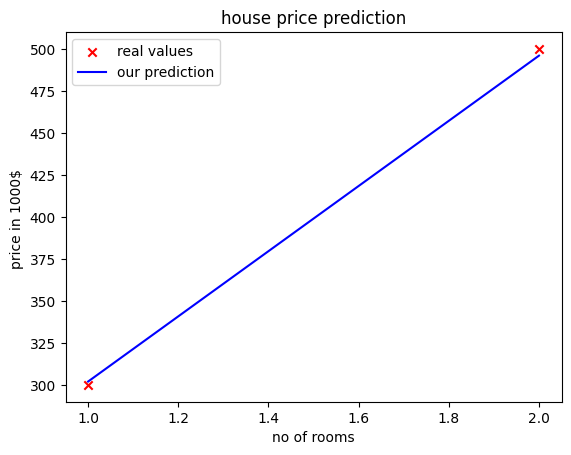

In [27]:
plt.scatter(x_train,y_train,marker='x', c='r',label='real values')
plt.title("house price prediction")
plt.xlabel("no of rooms")
plt.ylabel("price in 1000$ ")

tmp_fwb = compute_model_output(x_train,194,108)

plt.plot(x_train,tmp_fwb,c='b',label='our prediction')
plt.legend()
